this one runs registration but allows only translation or only rotation to be tested at one time. this is because preliminary results show that rotation is working well but translation is not

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

from diffdrr.drr import DRR
from diffdrr.metrics import NormalizedCrossCorrelation2d
from diffdrr.pose import RigidTransform
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms

device = torch.device('cpu')

with open('../outputs/dataset_config.json') as f:
    cfg = json.load(f)

SUBJECT_ID = cfg['subject_id']
SUBSAMPLE  = cfg['subsample']
FRAME_IDX  = 20

deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)

drr = DRR(
    deepfluoro.subject,
    sdd=deepfluoro.focal_len,
    height=deepfluoro.height // SUBSAMPLE,
    delx=deepfluoro.delx * SUBSAMPLE,
    x0=deepfluoro.x0,
    y0=deepfluoro.y0,
).to(device)

gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_mat = gt_pose.matrix[0].numpy()

print(f'✅ Ready — Subject {SUBJECT_ID}, Frame {FRAME_IDX}')

✅ Ready — Subject 1, Frame 20


In [ ]:
class PoseOptimizer(nn.Module):
    def __init__(self, initial_pose):
        super().__init__()
        mat = initial_pose.matrix[0]
        self.log_rot = nn.Parameter(self._log_SO3(mat[:3,:3]).clone().detach())
        self.trans   = nn.Parameter(mat[:3,3].clone().detach())

    @staticmethod
    def _log_SO3(R):
        theta = torch.acos(((R.trace()-1)/2).clamp(-1+1e-6, 1-1e-6))
        if theta.abs() < 1e-6: return torch.zeros(3)
        return (theta/(2*torch.sin(theta))) * torch.stack([
            R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]
        ])

    @staticmethod
    def _exp_SO3(v):
        theta = v.norm()
        if theta < 1e-6: return torch.eye(3)
        k = v/theta
        K = torch.zeros(3,3)
        K[0,1],K[0,2] = -k[2],k[1]
        K[1,0],K[1,2] =  k[2],-k[0]
        K[2,0],K[2,1] = -k[1],k[0]
        return torch.eye(3) + torch.sin(theta)*K + (1-torch.cos(theta))*(K@K)

    def get_pose(self):
        R = self._exp_SO3(self.log_rot)
        mat = torch.eye(4)
        mat[:3,:3] = R
        mat[:3,3]  = self.trans
        return RigidTransform(mat.unsqueeze(0))


def make_translation_perturbation(gt_pose, dx=0, dy=0, dz=0):
    """Perturb only translation, keep rotation exactly at GT."""
    mat = gt_pose.matrix.clone()
    mat[0, :3, 3] += torch.tensor([dx, dy, dz], dtype=torch.float32)
    return RigidTransform(mat)


def make_rotation_perturbation(gt_pose, rx_deg=0, ry_deg=0, rz_deg=0):
    """Perturb only rotation, keep translation exactly at GT."""
    mat = gt_pose.matrix.clone()
    rx, ry, rz = [torch.deg2rad(torch.tensor(a, dtype=torch.float32))
                  for a in (rx_deg, ry_deg, rz_deg)]
    cx,cy,cz = torch.cos(rx),torch.cos(ry),torch.cos(rz)
    sx,sy,sz = torch.sin(rx),torch.sin(ry),torch.sin(rz)
    Rx = torch.tensor([[1,0,0],[0,cx,-sx],[0,sx,cx]])
    Ry = torch.tensor([[cy,0,sy],[0,1,0],[-sy,0,cy]])
    Rz = torch.tensor([[cz,-sz,0],[sz,cz,0],[0,0,1]])
    dR = (Rz @ Ry @ Rx).float()
    mat[0, :3, :3] = dR @ mat[0, :3, :3]
    return RigidTransform(mat)


def run_registration(gt_img, gt_pose, init_pose, n_iter=200):
    """Run Adam registration, return history and final pose."""
    target   = transform(gt_img).to(device)
    ncc_fn   = NormalizedCrossCorrelation2d(patch_size=9)
    pose_opt = PoseOptimizer(init_pose.to(device)).to(device)

    optimizer = torch.optim.Adam([
        {'params': pose_opt.log_rot, 'lr': 1e-3},
        {'params': pose_opt.trans,   'lr': 1.0},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_iter, eta_min=1e-5)

    history = {'ncc': [], 'trans_err': [], 'rot_err': [],
               'trans_x': [], 'trans_y': [], 'trans_z': []}

    for i in range(n_iter):
        optimizer.zero_grad()
        rendered_t = transform(drr(pose_opt.get_pose()))
        loss = -ncc_fn(rendered_t.to(device), target)
        loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            cur_mat   = pose_opt.get_pose().matrix[0].detach().cpu().numpy()
            trans_err = np.linalg.norm(cur_mat[:3,3] - gt_mat[:3,3])
            rot_mat   = cur_mat[:3,:3] @ gt_mat[:3,:3].T
            rot_err   = np.degrees(np.arccos(np.clip((np.trace(rot_mat)-1)/2, -1, 1)))
            # Per-axis translation error
            per_axis  = cur_mat[:3,3] - gt_mat[:3,3]
            history['ncc'].append(-loss.item())
            history['trans_err'].append(float(trans_err))
            history['rot_err'].append(float(rot_err))
            history['trans_x'].append(float(abs(per_axis[0])))
            history['trans_y'].append(float(abs(per_axis[1])))
            history['trans_z'].append(float(abs(per_axis[2])))

    return history, pose_opt.get_pose()


print('✅ Classes and functions defined')

✅ Classes and functions defined


In [ ]:
# Three seeds = three magnitudes along different axes
# Rotation is held exactly at GT — only translation varies
# trans_experiments = {
#     'In-plane X (±10mm)':  make_translation_perturbation(gt_pose, dx=10,  dy=0,  dz=0),
#     'In-plane Y (±10mm)':  make_translation_perturbation(gt_pose, dx=0,  dy=10,  dz=0),
#     'Depth Z (±10mm)':     make_translation_perturbation(gt_pose, dx=0,  dy=0,  dz=10),
# }

SEEDS = [1, 10, 100]
TRANS_MAG = 10.0  # mm — max per axis

trans_experiments = {}
for seed in SEEDS:
    torch.manual_seed(seed)
    dt = torch.FloatTensor(3).uniform_(-TRANS_MAG, TRANS_MAG)
    trans_experiments[f'Seed {seed} (Δ={dt.numpy().round(1)})'] = \
        make_translation_perturbation(gt_pose, dx=dt[0].item(), dy=dt[1].item(), dz=dt[2].item())

trans_histories = {}
trans_poses     = {}

print('Experiment 1: Translation-only perturbations')
print('Rotation held at GT — isolating translation recovery\n')

for name, init_pose in trans_experiments.items():
    init_t = init_pose.matrix[0, :3, 3].numpy()
    init_err = np.linalg.norm(init_t - gt_mat[:3, 3])
    print(f'  {name}  |  initial error: {init_err:.2f} mm')
    h, final = run_registration(gt_img, gt_pose, init_pose, n_iter=200)
    trans_histories[name] = h
    trans_poses[name]     = final
    print(f'  → final trans: {h["trans_err"][-1]:.2f} mm  |  '
          f'rot: {h["rot_err"][-1]:.2f}°  |  NCC: {h["ncc"][-1]:.4f}\n')

print('✅ Translation experiment complete')

Experiment 1: Translation-only perturbations
Rotation held at GT — isolating translation recovery

  Seed 1 (Δ=[ 5.2 -4.4 -1.9])  |  initial error: 7.06 mm
  → final trans: 2.10 mm  |  rot: 0.09°  |  NCC: 0.6212

  Seed 10 (Δ=[-0.8 -0.3 -3.8])  |  initial error: 3.86 mm
  → final trans: 1.96 mm  |  rot: 0.13°  |  NCC: 0.6226

  Seed 100 (Δ=[-7.8  6.3 -4.7])  |  initial error: 11.08 mm
  → final trans: 3.69 mm  |  rot: 0.28°  |  NCC: 0.6232

✅ Translation experiment complete


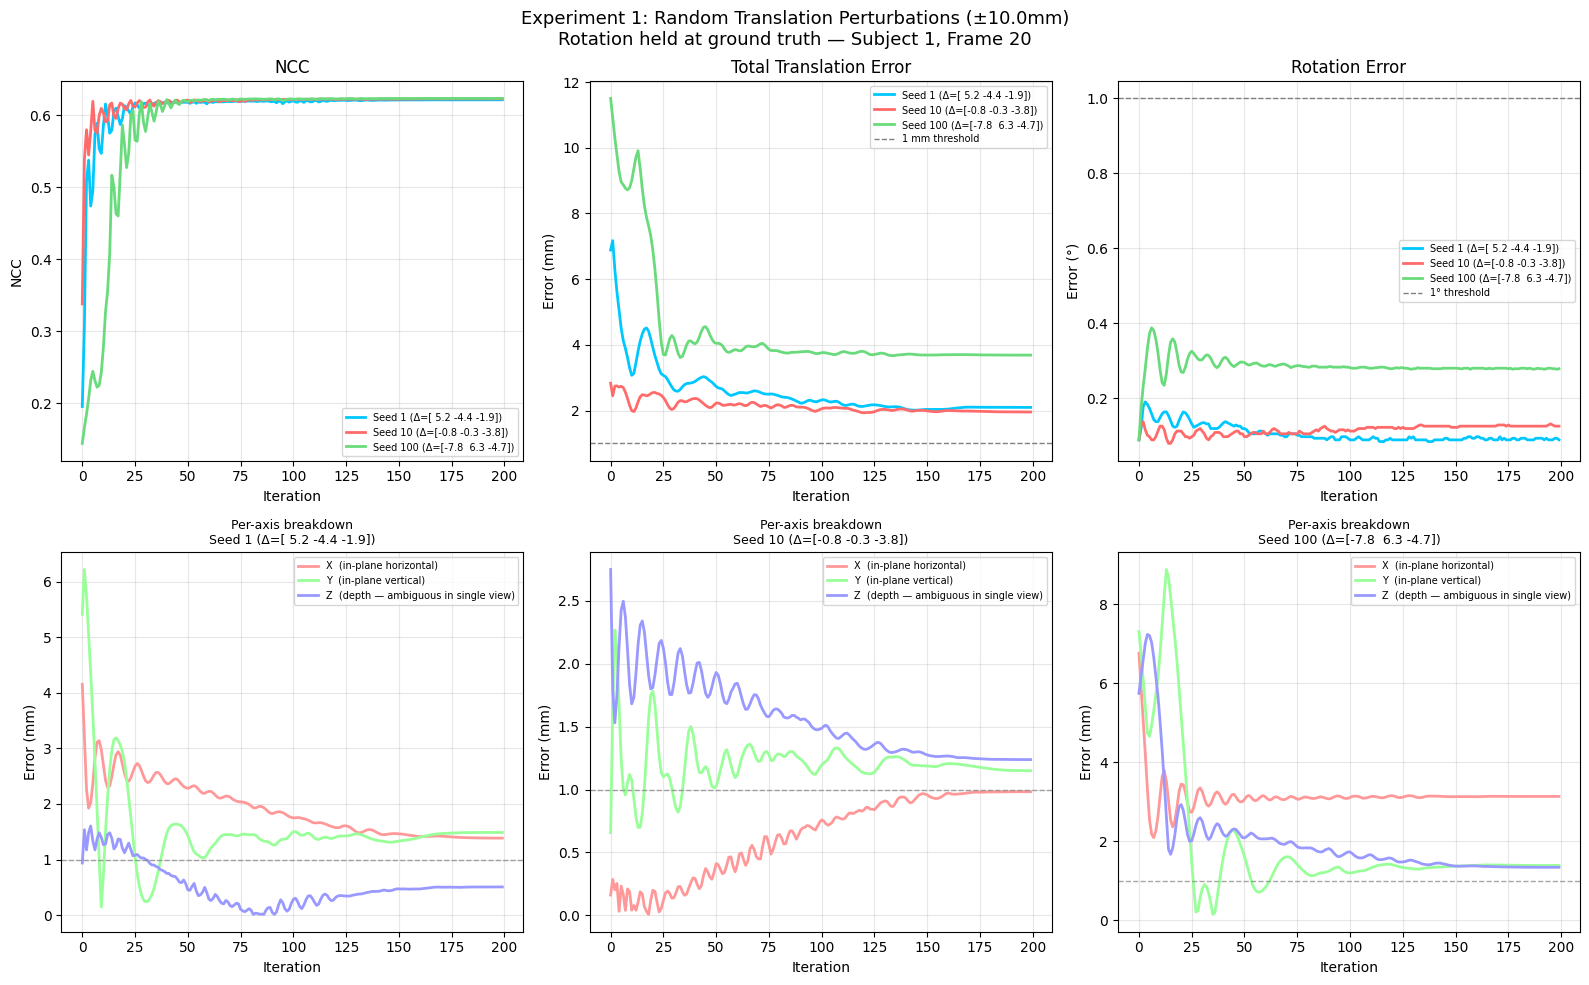

Saved: experiment_translation.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Experiment 1: Random Translation Perturbations (±{TRANS_MAG}mm)\n'
             f'Rotation held at ground truth — Subject {SUBJECT_ID}, Frame {FRAME_IDX}',
             fontsize=13)

colors = ['#00c8ff', '#ff6b6b', '#69db7c']
iters  = range(200)

# ── Row 1: Standard convergence curves ────────────────────────────────────────
for (name, h), col in zip(trans_histories.items(), colors):
    axes[0,0].plot(h['ncc'],       color=col, lw=2, label=name)
    axes[0,1].plot(h['trans_err'], color=col, lw=2, label=name)
    axes[0,2].plot(h['rot_err'],   color=col, lw=2, label=name)

axes[0,0].set_title('NCC')
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('NCC')

axes[0,1].set_title('Total Translation Error')
axes[0,1].set_xlabel('Iteration')
axes[0,1].set_ylabel('Error (mm)')
axes[0,1].axhline(1.0, color='gray', ls='--', lw=1, label='1 mm threshold')

axes[0,2].set_title('Rotation Error')
axes[0,2].set_xlabel('Iteration')
axes[0,2].set_ylabel('Error (°)')
axes[0,2].axhline(1.0, color='gray', ls='--', lw=1, label='1° threshold')

for ax in axes[0]:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# ── Row 2: Per-axis translation breakdown ─────────────────────────────────────
axis_colors = {'X': '#ff9999', 'Y': '#99ff99', 'Z': '#9999ff'}
axis_labels = {'X': 'X  (in-plane horizontal)',
               'Y': 'Y  (in-plane vertical)',
               'Z': 'Z  (depth — ambiguous in single view)'}

for col_idx, (name, h) in enumerate(trans_histories.items()):
    ax = axes[1, col_idx]
    ax.plot(h['trans_x'], color=axis_colors['X'], lw=2, label=axis_labels['X'])
    ax.plot(h['trans_y'], color=axis_colors['Y'], lw=2, label=axis_labels['Y'])
    ax.plot(h['trans_z'], color=axis_colors['Z'], lw=2, label=axis_labels['Z'])
    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'Per-axis breakdown\n{name}', fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Error (mm)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/experiment_translation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment_translation.png')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Experiment 1: Translation-Only Perturbations\n'
             '(Rotation held at ground truth)', fontsize=13)

colors = ['#00c8ff', '#ff6b6b', '#69db7c']
iters  = range(200)

for (name, h), col in zip(trans_histories.items(), colors):
    axes[0].plot(h['ncc'],       color=col, lw=2, label=name)
    axes[1].plot(h['trans_err'], color=col, lw=2, label=name)
    axes[2].plot(h['rot_err'],   color=col, lw=2, label=name)

axes[0].set_title('NCC (↑ better)');             axes[0].set_xlabel('Iteration')
axes[1].set_title('Translation Error mm (↓)');   axes[1].set_xlabel('Iteration')
axes[2].set_title('Rotation Error ° (↓)');       axes[2].set_xlabel('Iteration')

axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='1 mm')
axes[2].axhline(1.0, color='gray', ls='--', lw=1, label='1°')

# Add per-axis breakdown for depth Z case
fig2, ax2 = plt.subplots(figsize=(8, 4))
h_depth = trans_histories['Depth Z (±10mm)']
ax2.plot(h_depth['trans_x'], color='#ff6b6b', lw=2, label='X error (mm)')
ax2.plot(h_depth['trans_y'], color='#69db7c', lw=2, label='Y error (mm)')
ax2.plot(h_depth['trans_z'], color='#00c8ff', lw=2, label='Z/depth error (mm)')
ax2.axhline(1.0, color='gray', ls='--', lw=1)
ax2.set_title('Depth Z perturbation — per-axis error breakdown\n'
              '(illustrates depth ambiguity in single-view X-ray)', fontsize=11)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Error (mm)')
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig('../outputs/depth_ambiguity.png', dpi=150, bbox_inches='tight')

for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('../outputs/experiment_translation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment_translation.png, depth_ambiguity.png')

In [ ]:
# Three axes of rotation — translation held exactly at GT
# rot_experiments = {
#     'Roll X (5°)':  make_rotation_perturbation(gt_pose, rx_deg=5,  ry_deg=0, rz_deg=0),
#     'Pitch Y (5°)': make_rotation_perturbation(gt_pose, rx_deg=0,  ry_deg=5, rz_deg=0),
#     'Yaw Z (5°)':   make_rotation_perturbation(gt_pose, rx_deg=0,  ry_deg=0, rz_deg=5),
# }

SEEDS = [1,10,20,30,50]
ROT_MAG = 5.0  # degrees — max per axis

rot_experiments = {}
for seed in SEEDS:
    torch.manual_seed(seed + 1000)  # different seed from translation
    dr = torch.FloatTensor(3).uniform_(-ROT_MAG, ROT_MAG)
    rot_experiments[f'Seed {seed} (Δ={dr.numpy().round(1)}°)'] = \
        make_rotation_perturbation(gt_pose, rx_deg=dr[0].item(), 
                                            ry_deg=dr[1].item(), 
                                            rz_deg=dr[2].item())

rot_histories = {}
rot_poses     = {}

print('Experiment 2: Rotation-only perturbations')
print('Translation held at GT — isolating rotation recovery\n')

for name, init_pose in rot_experiments.items():
    init_r = init_pose.matrix[0, :3, :3].numpy()
    rot_m  = init_r @ gt_mat[:3,:3].T
    init_rot_err = np.degrees(np.arccos(np.clip((np.trace(rot_m)-1)/2, -1, 1)))
    print(f'  {name}  |  initial rot error: {init_rot_err:.2f}°')
    h, final = run_registration(gt_img, gt_pose, init_pose, n_iter=20)
    rot_histories[name] = h
    rot_poses[name]     = final
    print(f'  → final trans: {h["trans_err"][-1]:.2f} mm  |  '
          f'rot: {h["rot_err"][-1]:.2f}°  |  NCC: {h["ncc"][-1]:.4f}\n')

print('✅ Rotation experiment complete')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Experiment 2: Rotation-Only Perturbations\n'
             '(Translation held at ground truth)', fontsize=13)

colors = ['#00c8ff', '#ff6b6b', '#69db7c']

for (name, h), col in zip(rot_histories.items(), colors):
    axes[0].plot(h['ncc'],       color=col, lw=2, label=name)
    axes[1].plot(h['trans_err'], color=col, lw=2, label=name)
    axes[2].plot(h['rot_err'],   color=col, lw=2, label=name)

axes[0].set_title('NCC (↑ better)');             axes[0].set_xlabel('Iteration')
axes[1].set_title('Translation Error mm (↓)');   axes[1].set_xlabel('Iteration')
axes[2].set_title('Rotation Error ° (↓)');       axes[2].set_xlabel('Iteration')

axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='1 mm')
axes[2].axhline(1.0, color='gray', ls='--', lw=1, label='1°')

for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('../outputs/experiment_rotation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment_rotation.png')

In [ ]:
print('='*70)
print('RESULTS SUMMARY')
print('='*70)
print()
print('EXPERIMENT 1 — Translation only (rotation = GT)')
print(f'{"Perturbation":25}  {"Init err":>10}  {"Final trans":>12}  {"Final rot":>10}  {"Success":>8}')
print('-'*70)
for name, h in trans_histories.items():
    init_err = 10.0  # fixed perturbation magnitude
    success = '✅' if h['rot_err'][-1] < 1.0 and h['trans_err'][-1] < 2.0 else '❌'
    print(f'{name:25}  {init_err:>10.1f}  {h["trans_err"][-1]:>12.2f}  '
          f'{h["rot_err"][-1]:>10.2f}  {success:>8}')

print()
print('EXPERIMENT 2 — Rotation only (translation = GT)')
print(f'{"Perturbation":25}  {"Init err":>10}  {"Final trans":>12}  {"Final rot":>10}  {"Success":>8}')
print('-'*70)
for name, h in rot_histories.items():
    init_err = 5.0
    success = '✅' if h['rot_err'][-1] < 1.0 and h['trans_err'][-1] < 2.0 else '❌'
    print(f'{name:25}  {init_err:>10.1f}  {h["trans_err"][-1]:>12.2f}  '
          f'{h["rot_err"][-1]:>10.2f}  {success:>8}')

print()
print('='*70)
print('GRUPP 2020 METHOD 1 BASELINE (intensity-only, no landmark init):')
print('  Success rate: 18%  |  Rot: 0.1±0.1°  |  Trans: 0.4±0.9mm')
print('  (successful registrations only, 366 images across 6 subjects)')
print('='*70)